# Cross-Ensemble Sybil Detector — LayerZero

Blends the XGBoost and LightGBM 3-seed ensembles by weighted probability averaging (soft voting):

```
final_score = w × P(Sybil | XGBoost) + (1 − w) × P(Sybil | LightGBM)
```

The models are not retrained here: the notebook reads the validation and test probabilities saved by
`03_xgboost_sybil` and `04_lightgbm_sybil`. `w` is selected on validation F1 (`sp.select_blend_weight`,
section 2); the test set is not used to choose it.

**Results**: section 3, saved to `results/06_cross_ensemble_sybil.json`. Runtime: seconds.

## Setup

In [1]:
import warnings
import matplotlib.pyplot as plt
import sybil_pipeline as sp
warnings.filterwarnings('ignore')

## 1. Load the XGBoost and LightGBM predictions

In [2]:
P = {}
for part in ['val', 'test']:
    x = sp.load_predictions('03_xgboost_sybil', part)
    l = sp.load_predictions('04_lightgbm_sybil', part)
    assert (x['addr'].to_numpy() == l['addr'].to_numpy()).all()   # same rows, same order
    P[part] = x.assign(prob_lgbm=l['prob_lgbm'])
y_val, y_test = P['val']['y'].to_numpy(), P['test']['y'].to_numpy()
xgb = {part: P[part]['prob_xgb'].to_numpy() for part in P}
lgbm = {part: P[part]['prob_lgbm'].to_numpy() for part in P}
print(f"Validation {len(y_val):,} rows, test {len(y_test):,} rows")

Validation 91,305 rows, test 130,435 rows


## 2. Blend weight (validation set only)

For each XGBoost weight *w* in 0.00 to 1.00 (step 0.02): blend the validation probabilities, take the
F1-maximizing threshold on validation, and record validation F1. The weight with the highest validation F1
is used.

Selected XGB weight = 0.06  (validation F1 = 0.7082)
Weights within 0.001 of the best validation F1: 0.00 to 0.12
Validation F1 at the original 0.40 weight: 0.7056


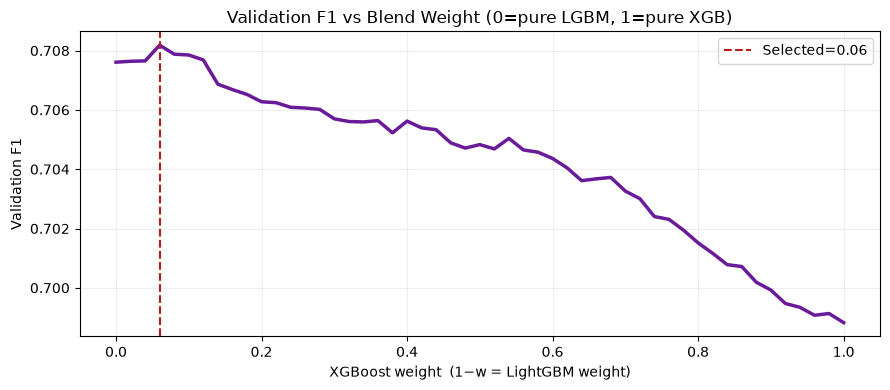

In [3]:
XGB_WEIGHT, val_f1 = sp.select_blend_weight(y_val, xgb['val'], lgbm['val'])
flat = sp.BLEND_WEIGHTS[val_f1 >= val_f1.max() - 0.001]
print(f'Selected XGB weight = {XGB_WEIGHT:.2f}  (validation F1 = {val_f1.max():.4f})')
print(f'Weights within 0.001 of the best validation F1: {flat.min():.2f} to {flat.max():.2f}')
print(f'Validation F1 at the original 0.40 weight: {val_f1[sp.BLEND_WEIGHTS == 0.40][0]:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sp.BLEND_WEIGHTS, val_f1, color='#6A1B9A', lw=2.5)
ax.axvline(XGB_WEIGHT, color='#B71C1C', lw=1.5, ls='--', label=f'Selected={XGB_WEIGHT:.2f}')
ax.set(xlabel='XGBoost weight  (1−w = LightGBM weight)', ylabel='Validation F1',
       title='Validation F1 vs Blend Weight (0=pure LGBM, 1=pure XGB)')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

ens = {part: XGB_WEIGHT * xgb[part] + (1 - XGB_WEIGHT) * lgbm[part] for part in ['val', 'test']}

## 3. Evaluate: individual models and ensemble

The individual rows recompute `03` and `04`'s metrics from their saved probabilities; `10_tie_out` checks
that they match.

=== XGBoost (tuned, 3-seed) ===
  Threshold : 0.5824
  Precision : 0.7196
  Recall    : 0.7205
  F1        : 0.7200
  AUROC     : 0.9657
  Avg Prec  : 0.7645
  Brier     : 0.0197

=== LightGBM (tuned, 3-seed) ===
  Threshold : 0.6001
  Precision : 0.7267
  Recall    : 0.7111
  F1        : 0.7188
  AUROC     : 0.9683
  Avg Prec  : 0.7696
  Brier     : 0.0194

=== Cross-Ensemble ===
  Threshold : 0.5035
  Precision : 0.6971
  Recall    : 0.7388
  F1        : 0.7173
  AUROC     : 0.9683
  Avg Prec  : 0.7699
  Brier     : 0.0194



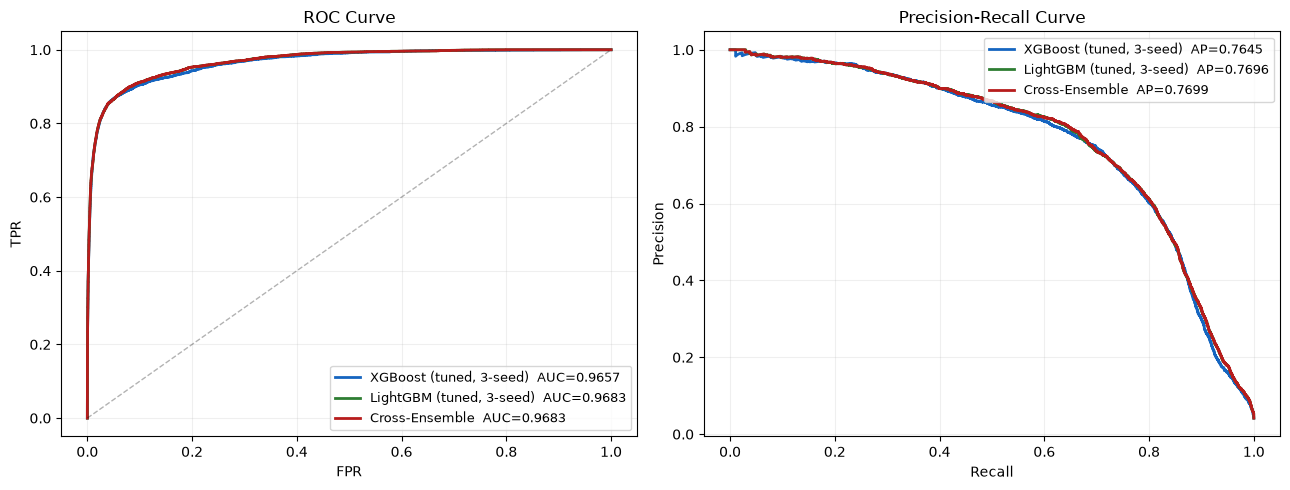

In [4]:
xgb_r  = sp.evaluate('XGBoost (tuned, 3-seed)',  y_val, xgb['val'],  y_test, xgb['test'])
lgbm_r = sp.evaluate('LightGBM (tuned, 3-seed)', y_val, lgbm['val'], y_test, lgbm['test'])
ens_r  = sp.evaluate('Cross-Ensemble',           y_val, ens['val'],  y_test, ens['test'])
for r in [xgb_r, lgbm_r, ens_r]:
    print(f"=== {r['name']} ==="); sp.print_metrics(r); print()
sp.plot_curves([xgb_r, lgbm_r, ens_r])

## 4. Agreement between the two models (threshold 0.5)

In [5]:
xgb_hi, lgbm_hi = xgb['test'] > 0.5, lgbm['test'] > 0.5
disagree = xgb_hi ^ lgbm_hi
for label, mask in [('Both predict Sybil', xgb_hi & lgbm_hi), ('Both predict Clean', ~xgb_hi & ~lgbm_hi),
                    ('Models disagree', disagree)]:
    n, n_syb = int(mask.sum()), int(y_test[mask].sum())
    print(f'  {label:<20}: {n:7,} addresses ({n_syb:,} true Sybil, {n - n_syb:,} true Clean)')
print(f'\nDisagreement zone = {disagree.mean()*100:.2f}% of test set')
for name, probs in [('Cross-ensemble', ens['test']), ('XGBoost alone', xgb['test']), ('LightGBM alone', lgbm['test'])]:
    print(f'  {name:<15} correct in the disagreement zone: '
          f'{((probs[disagree] > 0.5) == y_test[disagree]).sum():,}/{int(disagree.sum()):,}')

  Both predict Sybil  :   5,462 addresses (3,951 true Sybil, 1,511 true Clean)
  Both predict Clean  : 124,270 addresses (1,338 true Sybil, 122,932 true Clean)
  Models disagree     :     703 addresses (174 true Sybil, 529 true Clean)

Disagreement zone = 0.54% of test set
  Cross-ensemble  correct in the disagreement zone: 366/703
  XGBoost alone   correct in the disagreement zone: 341/703
  LightGBM alone  correct in the disagreement zone: 362/703


## 5. Operating points (cross-ensemble)

Precision, recall and counts on the test set at fixed thresholds and at the threshold chosen on validation
(whose row equals the reported test metrics).

In [6]:
print(sp.operating_points(y_test, ens['test'], ens_r['threshold']).round(4).to_string(index=False))

 threshold  precision  recall     f1  flagged  false_pos                 note
    0.9500     0.8746  0.4787 0.6187     2990        375                     
    0.9000     0.8405  0.5594 0.6717     3636        580                     
    0.8500     0.8208  0.6121 0.7013     4074        730                     
    0.8000     0.8047  0.6405 0.7133     4348        849                     
    0.7500     0.7859  0.6652 0.7205     4624        990                     
    0.7000     0.7636  0.6813 0.7201     4874       1152                     
    0.5035     0.6971  0.7388 0.7173     5790       1754 validation threshold
    0.5000     0.6959  0.7403 0.7174     5811       1767                     


## Save results

Scalar metrics go to `results/06_cross_ensemble_sybil.json` with the code commit; ensemble test
probabilities go to `output/` for `10_tie_out`.

In [7]:
R = {nb: sp.load_results(nb) for nb in ['03_xgboost_sybil', '04_lightgbm_sybil']}
sp.save_results([xgb_r, lgbm_r, ens_r], '06_cross_ensemble_sybil', extra=dict(
    xgb_weight=XGB_WEIGHT, val_f1_by_weight=dict(zip(sp.BLEND_WEIGHTS.tolist(), val_f1.round(4).tolist())),
    params=dict(xgb=R['03_xgboost_sybil']['params'], lgbm=R['04_lightgbm_sybil']['params']),
    rounds=dict(xgb=R['03_xgboost_sybil']['rounds'], lgbm=R['04_lightgbm_sybil']['rounds']),
    disagreement_n=int(disagree.sum()), disagreement_pct=float(disagree.mean() * 100)))
for part in ['val', 'test']:
    path = f'output/pred_06_cross_ensemble_sybil_{part}.parquet'
    P[part][['addr', 'category', 'y']].assign(prob_ens=ens[part]).to_parquet(path, index=False)
    print(f'Saved {path}')

Saved results/06_cross_ensemble_sybil.json
Saved output/pred_06_cross_ensemble_sybil_val.parquet


Saved output/pred_06_cross_ensemble_sybil_test.parquet
